# Visual Product Search Engine — BLIP-2 Captioning

This notebook generates BLIP-2 captions for all cropped clothing images.

---

### What BLIP-2 does
Takes a cropped clothing image and generates a text description like:
> 'a white slim-fit sleeveless top with a v-neckline'

These captions are used in the CLIP embedding step:
```
v_i = alpha * CLIP_image(crop) + (1 - alpha) * CLIP_text(caption)
```

---

### BLIP-2 is FROZEN — no training at all
PDF says: 'BLIP-2 and YOLO stay frozen.'

---

### Speed settings
| Setting | Value | Why |
|---------|-------|-----|
| num_beams | 1 (greedy) | ~4x faster than beam search |
| batch_size | 16 | fits on T4 GPU |
| max_new_tokens | 30 | shorter captions = faster |

Expected time: ~2.5 hours for all 38k images

---

### Inputs
- `yolo-bbox-crops-v1` — annotation bbox cropped images + master_crops.csv

### Outputs
- `captions.json` — all gallery + train captions
- `gallery_captions.json` — gallery only
- `train_captions.json` — train only

## Step 1: Install and Import Libraries

In [1]:
!pip install transformers accelerate bitsandbytes Pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.0 MB/s eta 0:00:00


In [2]:
import os
import json
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device          : {DEVICE}')
print(f'PyTorch version : {torch.__version__}')
print('All libraries imported successfully!')

Device          : cuda
PyTorch version : 2.10.0+cu128
All libraries imported successfully!


## Step 2: Configuration

Change RUN_MODE to control which images are captioned:
- `'all'` -> gallery + train together (~2.5 hrs, recommended)
- `'gallery'` -> gallery only (~50-60 min)
- `'train'` -> train only (~90-100 min)

In [3]:
# ============================================================
#  CHANGE THIS to control which images to caption
# ============================================================
RUN_MODE = 'all'   # Options: 'all', 'gallery', 'train'
# ============================================================

# Input — NEW bbox crops dataset
CROPS_DATASET = '/kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1'

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Speed settings
BATCH_SIZE       = 16
MAX_NEW_TOKENS   = 30
NUM_BEAMS        = 1    # greedy decoding — fastest
CHECKPOINT_EVERY = 500

# Verify
status = 'Found' if os.path.exists(CROPS_DATASET) else 'NOT FOUND'
print(f'[{status}] CROPS_DATASET: {CROPS_DATASET}')
print(f'\nConfiguration:')
print(f'  RUN_MODE         : {RUN_MODE}')
print(f'  BATCH_SIZE       : {BATCH_SIZE}')
print(f'  MAX_NEW_TOKENS   : {MAX_NEW_TOKENS}')
print(f'  NUM_BEAMS        : {NUM_BEAMS}  (1 = greedy, fastest)')

if os.path.exists(CROPS_DATASET):
    print('\nFiles in crops dataset:')
    for item in sorted(os.listdir(CROPS_DATASET))[:15]:
        print(f'  {item}')

[Found] CROPS_DATASET: /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1

Configuration:
  RUN_MODE         : all
  BATCH_SIZE       : 16
  MAX_NEW_TOKENS   : 30
  NUM_BEAMS        : 1  (1 = greedy, fastest)

Files in crops dataset:
  data
  gallery_crops.csv
  master_crops.csv
  query_crops.csv
  train_crops.csv


## Step 3: Load Master CSV and Remap Crop Paths

The crop_path column in the CSV was saved as /kaggle/working/data/bbox_crops/...
Now the crops are in the Kaggle input dataset, so we remap the paths.

In [4]:
csv_path = os.path.join(CROPS_DATASET, 'master_crops.csv')
df = pd.read_csv(csv_path)

print(f'Loaded master_crops.csv: {len(df):,} rows')
print(f'Columns: {df.columns.tolist()}')
print()
print('Split distribution:')
print(df['split'].value_counts().to_string())

def remap_crop_path(old_path):
    """
    Remap from /kaggle/working/data/bbox_crops/...
    to /kaggle/input/datasets/harshitabansal307yolo-bbox-crops-v1/data/bbox_crops/...
    """
    if pd.isna(old_path):
        return old_path
    relative = old_path.replace('/kaggle/working/', '')
    return os.path.join(CROPS_DATASET, relative)

df['crop_path_new'] = df['crop_path'].apply(remap_crop_path)
df['crop_exists']   = df['crop_path_new'].apply(
    lambda p: os.path.exists(p) if isinstance(p, str) else False
)

print('\nSample remapped paths:')
for p in df['crop_path_new'].head(3):
    print(f'  [{"OK" if os.path.exists(p) else "MISSING"}] {p}')

print(f'\nCrops found on disk: {df["crop_exists"].sum():,} / {len(df):,}')

Loaded master_crops.csv: 52,712 rows
Columns: ['image_name', 'item_id', 'split', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2', 'crop_path', 'crop_exists', 'crop_method']

Split distribution:
split
train      25882
query      14218
gallery    12612

Sample remapped paths:
  [OK] /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1/data/bbox_crops/WOMEN/Dresses/id_00000002/02_1_front.jpg
  [OK] /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1/data/bbox_crops/WOMEN/Dresses/id_00000002/02_2_side.jpg
  [OK] /kaggle/input/datasets/harshitabansal307/yolo-bbox-crops-v1/data/bbox_crops/WOMEN/Dresses/id_00000002/02_4_full.jpg

Crops found on disk: 52,712 / 52,712


## Step 4: Filter Images Based on RUN_MODE

In [5]:
if RUN_MODE == 'all':
    splits_to_run = ['gallery', 'train']
elif RUN_MODE == 'gallery':
    splits_to_run = ['gallery']
elif RUN_MODE == 'train':
    splits_to_run = ['train']
else:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')

caption_df = df[
    (df['split'].isin(splits_to_run)) &
    (df['crop_exists'] == True)
].reset_index(drop=True)

gallery_df = df[(df['split'] == 'gallery') & (df['crop_exists'])].reset_index(drop=True)
train_df   = df[(df['split'] == 'train')   & (df['crop_exists'])].reset_index(drop=True)

print(f'RUN_MODE           : {RUN_MODE}')
print(f'Gallery available  : {len(gallery_df):,}')
print(f'Train available    : {len(train_df):,}')
print(f'Images to caption  : {len(caption_df):,}')

RUN_MODE           : all
Gallery available  : 12,612
Train available    : 25,882
Images to caption  : 38,494


## Step 5: Load BLIP-2 Model (Frozen)

Using BitsAndBytesConfig for 8-bit quantization — correct for newer transformers.
Internet must be ON — downloads ~6GB from HuggingFace on first run.

In [6]:
MODEL_NAME = 'Salesforce/blip2-opt-2.7b'

print(f'Loading BLIP-2: {MODEL_NAME}')
print('First run downloads ~6GB — please wait...')

processor = Blip2Processor.from_pretrained(MODEL_NAME, use_fast=False)

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16
)

model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.float16
)

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False
model.eval()

print('BLIP-2 loaded and frozen!')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Loading BLIP-2: Salesforce/blip2-opt-2.7b
First run downloads ~6GB — please wait...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded and frozen!
Trainable parameters: 0


## Step 6: Test on Sample Images

Run on 4 random crops to verify captions look reasonable.

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image  : 01_2_side.jpg
Caption: a woman in a colorful dress is looking at a camera



The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image  : 04_2_side.jpg
Caption: a woman in jeans and a white top



The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


Image  : 02_7_additional.jpg
Caption: a woman wearing a pair of shorts with a high waist

Image  : 01_2_side.jpg
Caption: a woman in a black shirt and shorts



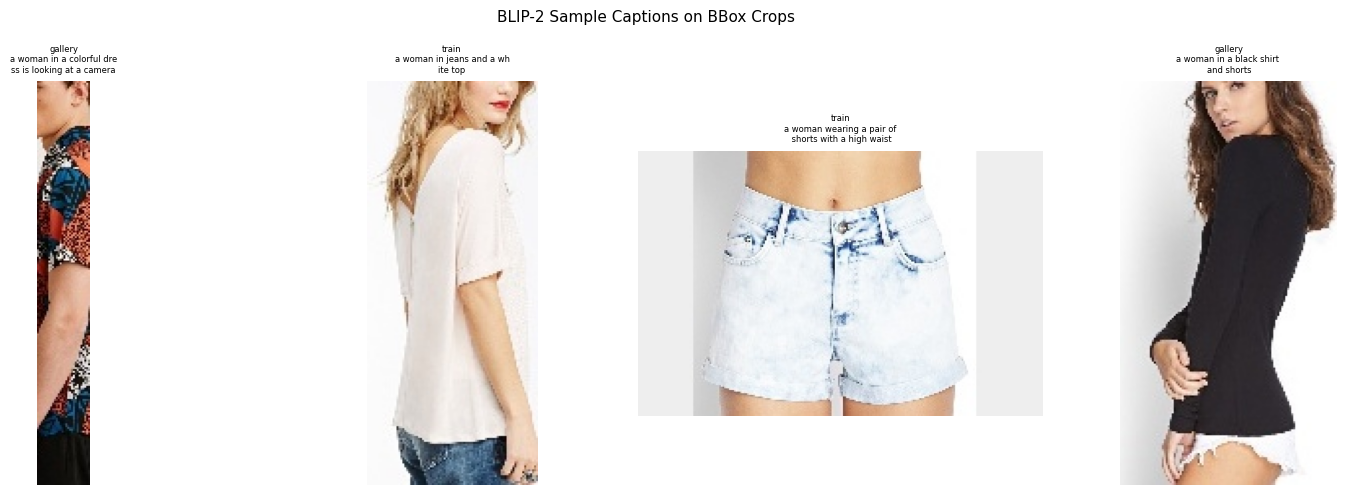

In [7]:
samples = caption_df.sample(4, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, (_, row) in enumerate(samples.iterrows()):
    try:
        img = Image.open(row['crop_path_new']).convert('RGB')
        inputs = processor(images=img, return_tensors='pt').to(DEVICE, torch.float16)
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=NUM_BEAMS
            )
        caption = processor.decode(generated_ids[0], skip_special_tokens=True).strip()

        axes[i].imshow(img)
        wrapped = '\n'.join([caption[j:j+25] for j in range(0, len(caption), 25)])
        axes[i].set_title(f'{row["split"]}\n{wrapped}', fontsize=6)
        axes[i].axis('off')
        print(f'Image  : {row["image_name"].split("/")[-1]}')
        print(f'Caption: {caption}')
        print()
    except Exception as e:
        print(f'Error on sample {i}: {e}')
        axes[i].axis('off')

plt.suptitle('BLIP-2 Sample Captions on BBox Crops', fontsize=11)
plt.tight_layout()
plt.show()

## Step 7: Generate Captions for All Images

Processes in batches of 16. Saves checkpoint every 500 images.
If notebook crashes, re-run and it will skip already-captioned images.

Expected time:
- Gallery only (~12k): ~50-60 min
- Train only (~26k): ~90-100 min
- All together (~38k): ~2.5 hrs

In [8]:
CAPTIONS_FILE = os.path.join(OUTPUT_DIR, 'captions.json')

# Load existing captions if resuming from a previous run
if os.path.exists(CAPTIONS_FILE):
    with open(CAPTIONS_FILE, 'r') as f:
        captions = json.load(f)
    print(f'Resuming — loaded {len(captions):,} existing captions')
else:
    captions = {}
    print('Starting fresh caption generation')

# Only process images not yet captioned
remaining = caption_df[
    ~caption_df['image_name'].isin(captions.keys())
].reset_index(drop=True)

print(f'Already captioned : {len(captions):,}')
print(f'Remaining         : {len(remaining):,}')
print()

failed = []

for batch_start in tqdm(range(0, len(remaining), BATCH_SIZE), desc='Captioning'):
    batch = remaining.iloc[batch_start : batch_start + BATCH_SIZE]

    images, image_names = [], []
    for _, row in batch.iterrows():
        try:
            img = Image.open(row['crop_path_new']).convert('RGB')
            images.append(img)
            image_names.append(row['image_name'])
        except:
            failed.append(row['image_name'])

    if not images:
        continue

    try:
        inputs = processor(
            images=images, return_tensors='pt', padding=True
        ).to(DEVICE, torch.float16)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=NUM_BEAMS
            )

        for idx, gen_id in enumerate(generated_ids):
            caption = processor.decode(gen_id, skip_special_tokens=True).strip()
            captions[image_names[idx]] = caption

    except Exception:
        # Batch failed — try one by one
        for img, name in zip(images, image_names):
            try:
                inp = processor(images=img, return_tensors='pt').to(DEVICE, torch.float16)
                with torch.no_grad():
                    gen_id = model.generate(**inp, max_new_tokens=MAX_NEW_TOKENS)
                caption = processor.decode(gen_id[0], skip_special_tokens=True).strip()
                captions[name] = caption
            except:
                failed.append(name)

    # Checkpoint
    if len(captions) % CHECKPOINT_EVERY < BATCH_SIZE:
        with open(CAPTIONS_FILE, 'w') as f:
            json.dump(captions, f)
        print(f'  Checkpoint: {len(captions):,} captions saved')

# Final save
with open(CAPTIONS_FILE, 'w') as f:
    json.dump(captions, f)

print(f'\nDone!')
print(f'Total captions : {len(captions):,}')
print(f'Failed         : {len(failed):,}')

Starting fresh caption generation
Already captioned : 0
Remaining         : 38,494



Captioning:   1%|▏         | 32/2406 [01:52<2:21:40,  3.58s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


  Checkpoint: 512 captions saved


Captioning:   3%|▎         | 63/2406 [03:45<2:20:50,  3.61s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


  Checkpoint: 1,008 captions saved


...

  Checkpoint: 37,504 captions saved


Captioning:  99%|█████████▊| 2375/2406 [2:24:57<02:05,  4.05s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


  Checkpoint: 38,000 captions saved


Captioning: 100%|██████████| 2406/2406 [2:26:45<00:00,  3.66s/it]


Done!
Total captions : 38,494
Failed         : 0


## Step 8: Split and Save Gallery and Train Captions

In [9]:
gallery_names = set(gallery_df['image_name'].tolist())
train_names   = set(train_df['image_name'].tolist())

gallery_captions = {k: v for k, v in captions.items() if k in gallery_names}
train_captions   = {k: v for k, v in captions.items() if k in train_names}

with open(os.path.join(OUTPUT_DIR, 'gallery_captions.json'), 'w') as f:
    json.dump(gallery_captions, f)

with open(os.path.join(OUTPUT_DIR, 'train_captions.json'), 'w') as f:
    json.dump(train_captions, f)

print(f'captions.json         : {len(captions):,}')
print(f'gallery_captions.json : {len(gallery_captions):,}')
print(f'train_captions.json   : {len(train_captions):,}')

captions.json         : 38,494
gallery_captions.json : 12,612
train_captions.json   : 25,882


## Step 9: Caption Quality Check

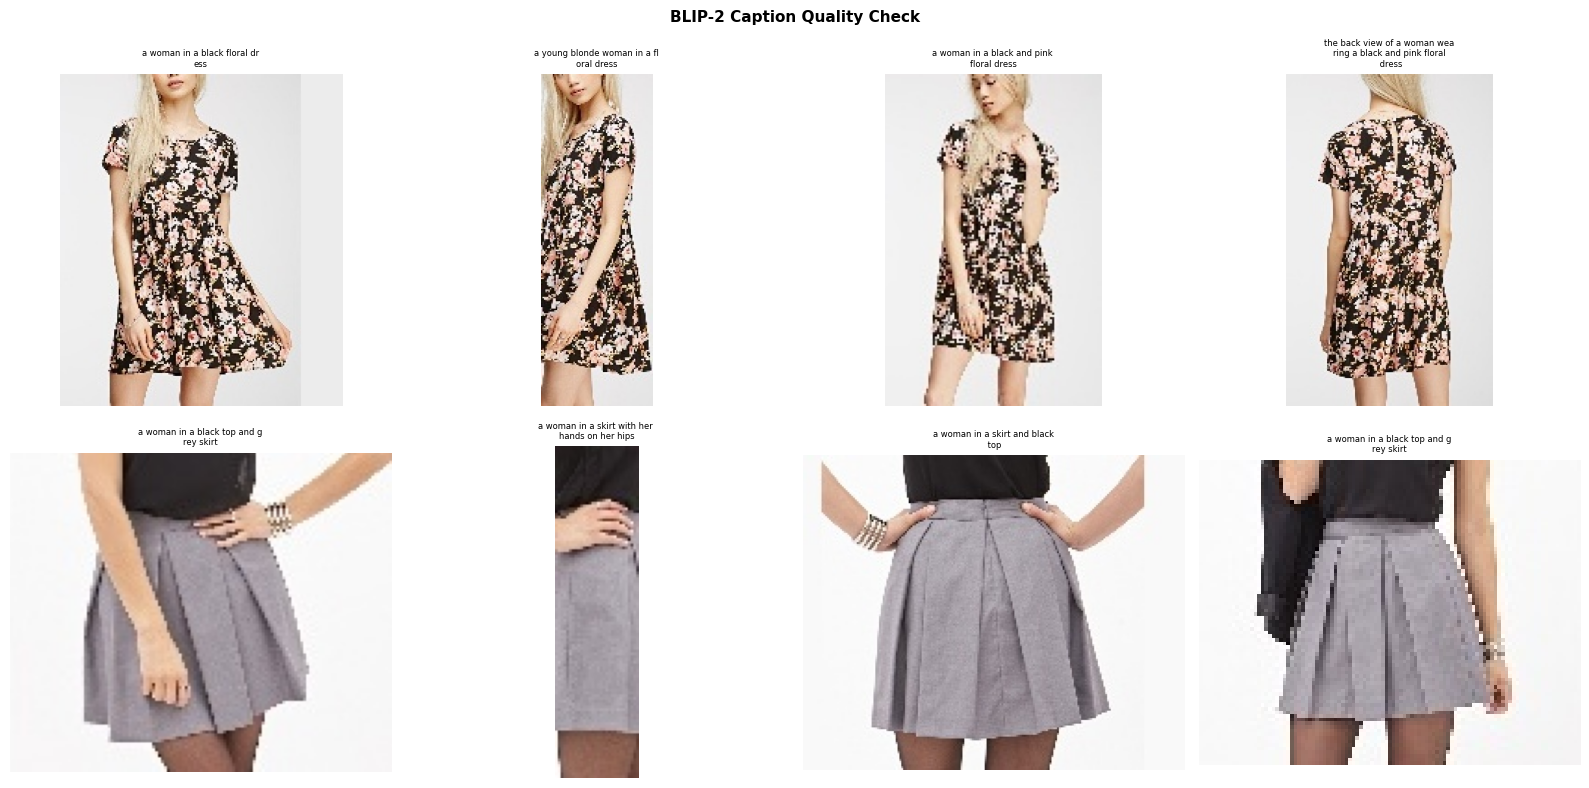

Caption length — mean: 9.7 words  min: 2  max: 30

Sample captions:
  02_1_front.jpg: a woman in a black floral dress
  02_2_side.jpg: a young blonde woman in a floral dress
  02_4_full.jpg: a woman in a black and pink floral dress
  02_7_additional.jpg: the back view of a woman wearing a black and pink floral dress
  02_1_front.jpg: a woman in a black top and grey skirt


In [10]:
sample_names = list(captions.keys())[:8]
sample_rows  = caption_df[caption_df['image_name'].isin(sample_names)].head(8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_rows.iterrows()):
    if i >= 8:
        break
    try:
        img     = Image.open(row['crop_path_new']).convert('RGB')
        caption = captions.get(row['image_name'], 'No caption')
        axes[i].imshow(img)
        wrapped = '\n'.join([caption[j:j+28] for j in range(0, min(len(caption), 84), 28)])
        axes[i].set_title(wrapped, fontsize=6)
        axes[i].axis('off')
    except:
        axes[i].axis('off')

plt.suptitle('BLIP-2 Caption Quality Check', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

lengths = [len(c.split()) for c in captions.values()]
print(f'Caption length — mean: {np.mean(lengths):.1f} words  min: {np.min(lengths)}  max: {np.max(lengths)}')

print('\nSample captions:')
for name, cap in list(captions.items())[:5]:
    print(f'  {name.split("/")[-1]}: {cap}')

## Step 10: Coverage Check

In [11]:
print('=== Caption Coverage ===')
print(f'Gallery : {len(gallery_captions):,} / {len(gallery_df):,}  ({len(gallery_captions)/len(gallery_df)*100:.1f}%)')
print(f'Train   : {len(train_captions):,} / {len(train_df):,}  ({len(train_captions)/len(train_df)*100:.1f}%)')

missing_gallery = gallery_df[~gallery_df['image_name'].isin(gallery_captions.keys())]
missing_train   = train_df[~train_df['image_name'].isin(train_captions.keys())]
print(f'\nMissing gallery : {len(missing_gallery):,}')
print(f'Missing train   : {len(missing_train):,}')

=== Caption Coverage ===
Gallery : 12,612 / 12,612  (100.0%)
Train   : 25,882 / 25,882  (100.0%)

Missing gallery : 0
Missing train   : 0


## Step 11: Final Summary

In [12]:
print('=' * 55)
print('         BLIP-2 CAPTIONING COMPLETE')
print('=' * 55)
print(f'  Model               : Salesforce/blip2-opt-2.7b')
print(f'  Status              : Frozen (no training)')
print(f'  Crop source         : Annotation BBox (ground truth)')
print(f'  Total captions      : {len(captions):,}')
print(f'  Gallery captions    : {len(gallery_captions):,}')
print(f'  Train captions      : {len(train_captions):,}')
print(f'  Failed              : {len(failed):,}')
print()
print('  Save as new Kaggle dataset:')
print('    captions.json')
print('    gallery_captions.json')
print('    train_captions.json')
print()
print('  Next notebook: CLIP Embeddings + FAISS Index (Config A and B)')
print('=' * 55)

         BLIP-2 CAPTIONING COMPLETE
  Model               : Salesforce/blip2-opt-2.7b
  Status              : Frozen (no training)
  Crop source         : Annotation BBox (ground truth)
  Total captions      : 38,494
  Gallery captions    : 12,612
  Train captions      : 25,882
  Failed              : 0

  Save as new Kaggle dataset:
    captions.json
    gallery_captions.json
    train_captions.json

  Next notebook: CLIP Embeddings + FAISS Index (Config A and B)
